In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import uproot
#from tqdm import tqdm

# Get Gamma points

In [495]:
energies = np.array([
    0.511,  # 68Ge
    0.662,  # 137Cs
    0.834,  # 54Mn
    1.25,  # 60Co
    1.461,  # 40K
    2.223,  # n-H
    2.614,  # 208Tl
    3.75,  # n-12C
    6.130,  # 16O*
    7.637   # n-56Fe
])

E_visible = np.array([
    1.022,  # 68Ge (2 x 0.511)
    0.662,  # 137Cs
    0.834,  # 54Mn
    2.505,  # 60Co (1.173 + 1.332)
    1.461,  # 40K
    2.223,  # n-H
    2.614,  # 208Tl
    4.945,  # n-12C (dominant branch)
    6.130,  # 16O*
    7.637   # n-56Fe
])

E_corrected = np.array([
    0.966,  # 68Ge
    0.649,  # 137Cs
    0.835,  # 54Mn
    2.490,  # 60Co
    1.493,  # 40K
    2.300,  # n-H
    2.701,  # 208Tl
    5.119,  # n-12C
    6.350,  # 16O*
    7.940   # n-56Fe
])


# Get nH

NameError: name 'nl' is not defined

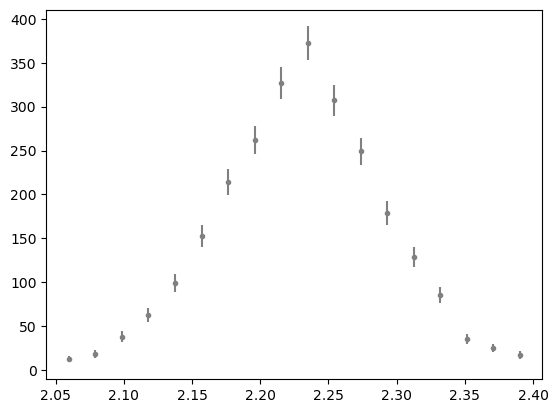

In [3]:
IBD_root = uproot.open("./IBD_all_reprodC_corrected.root")
ibd_d = IBD_root["events/energy_d_omilrec"].array(library="np")
#ibd_en = IBD_root['events']['energy_d_omilrec'].axes[0].edges()
ibd_bins = np.linspace(2.05,2.4,19)
ibd_data, _ = np.histogram(ibd_d, ibd_bins)
ibd_centers = (ibd_bins[:-1] + ibd_bins[1:]) / 2 
ibd_err = np.sqrt(ibd_data)
plt.errorbar(ibd_centers, ibd_data, yerr=ibd_err, ls='none', marker='.', color='gray')
ibd_pred = nl.nH_prediction(ibd_centers, 1.055, 12e-3, 0.3)
print(np.sum(ibd_pred))
plt.plot(ibd_centers, 2.5*ibd_pred, color='gray')

# Get B12

63633.0


[]

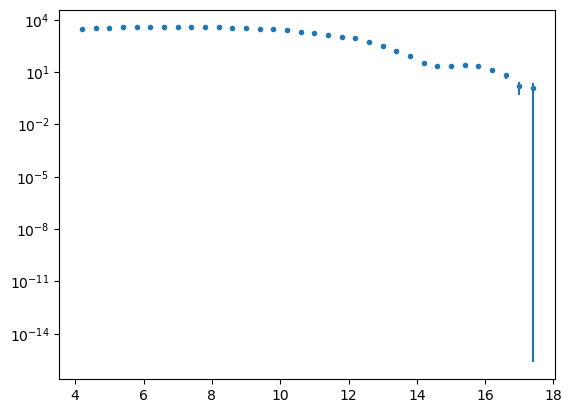

In [6]:
# Assuming your file is named 'data.txt' and is in the same directory.
#boron_root = uproot.open("./B12_difference_spectrum_Oct29_samemuon_neucut.root")
boron_root = uproot.open("./B12_IHEP_Chengzhuo.root")

#n12_etrue, n12 = np.loadtxt(nitro, skiprows=1, unpack=True)
#for Irvine B12
'''
b12_sig = boron_root['h_sig'].values()
#print(np.sum(b12_sig))
b12_bkg = boron_root['h_bkg'].values()
b12_meas = boron_root['h_diff'].values()
bmask = b12_meas > 0
b12_meas = b12_meas[bmask]
b12_edges = boron_root['h_diff'].axes[0].edges()
b12_erec = (b12_edges[:-1] + b12_edges[1:]) / 2 
b12_erec = b12_erec[bmask]

print(len(b12_meas))
print(len(b12_erec))
b12_err = np.sqrt(b12_sig) + (56/100)*np.sqrt(b12_bkg)

'''
#for IHEP B12
b12_meas = boron_root['b12_FV'].values()
print(np.sum(b12_meas))
bmask = b12_meas > 0
b12_meas = b12_meas[bmask]
b12_edges = boron_root['b12_FV'].axes[0].edges()
b12_erec = (b12_edges[:-1] + b12_edges[1:]) / 2 
b12_erec= b12_erec[bmask]
b12_err = np.sqrt(b12_meas)


b12_meas, b12_erec, b12_err = rebin_histogram(b12_erec, b12_meas, 0.4, b12_err)
data_mask = (b12_erec < 15) & (b12_erec > 4) # cut spectrum
plt.errorbar(b12_erec, b12_meas, yerr=b12_err, ls='none', marker='.')
plt.semilogy()

Index(['Energy', 'Counts', 'Error'], dtype='object')
Index(['Energy', 'Difference', 'Error'], dtype='object')
[5694. 6477. 6866. 7207. 7353. 7125. 6751. 6107. 5564. 4673. 3946. 3210.
 1997. 1297.  617.  240.   97.   71.   35.   38.   13.]


[]

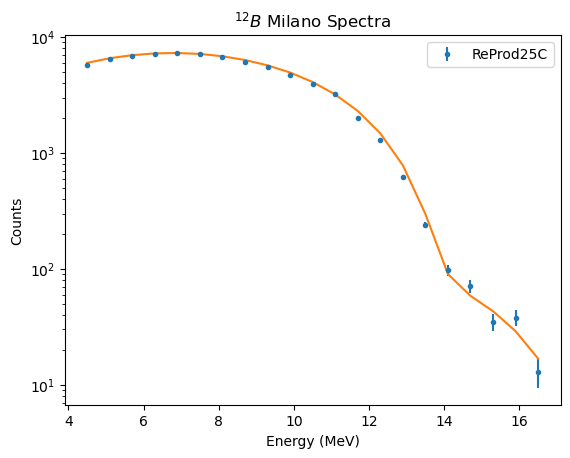

In [68]:
#MILANO
boron2 = pd.read_csv('B12_20251031_v2.csv')
#boron = pd.read_csv('energy_diff_data_Milano_01.txt', sep='\\s+', engine='python')
#boron = pd.read_csv('energy_spectrum_JV_MC_2_5_MeV_Milano.txt', sep='\\s+', engine='python')
boron = pd.read_csv('energy_spectrum_JV_Milano_energy_correction_no_unicity.txt', sep='\\s+', engine='python')

print(boron2.keys())
print(boron.keys())
b12_erec = boron['Energy']
#b12_meas = boron['Counts']
b12_meas = boron['Difference']
b12_err = boron['Error']
b12_meas, b12_erec, b12_err = rebin_histogram(b12_erec, b12_meas, 0.6, b12_err)
b_meas, b_erec, b_err = rebin_histogram(boron2['Energy'], boron2['Counts'], 0.6,  boron2['Error'])

data_mask = (b12_erec < 17) & (b12_erec > 4) & (b12_meas>0)
#data_mask = (b12_erec < 17.6) & (b12_erec > 4) # cut spectrum
benergy, nenergy, bbins = nl.B12_prediction(b12_erec[data_mask], *popt[0:3], alpha=popt[7])
plt.errorbar(b12_erec[data_mask], b12_meas[data_mask], yerr=b12_err[data_mask], ls='none', marker='.', label='ReProd25C')
#plt.errorbar(b_erec[data_mask], b_meas[data_mask], yerr=b_err[data_mask], ls='none', marker='.', label='ReProd25B')
plt.plot(bbins, 3*benergy + 0.1*nenergy)
print(b12_meas[data_mask])
plt.legend()
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts')
plt.title(r"$^{12}B$ Milano Spectra")
plt.semilogy()
#plt.savefig('b12_reprods.png')

# Get C11

[ 382  719  977 1113 1112  931  869  664  468  239   97   31    5]


<ErrorbarContainer object of 3 artists>

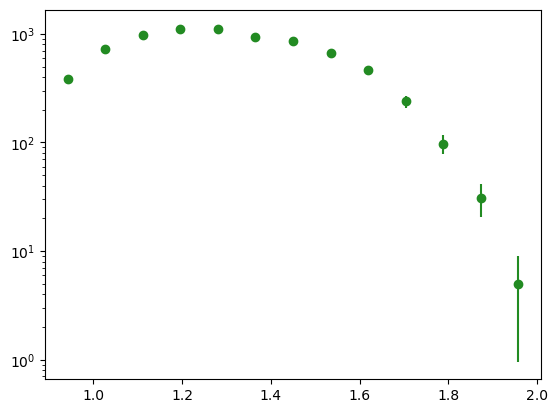

In [7]:
#carbon_root = uproot.open("./C11_MB.root")
#carbon_root = uproot.open("./C11_0927_1004_OReco.root")
carbon_root = uproot.open("./C11_0930_1005_ReProdC_JVOM.root")
sig_tree = carbon_root["Sig"]
bkg_tree = carbon_root["Bkg"]

#get data from trees
sig_data = sig_tree['ORecoE'].array(library="np")
bkg_data = bkg_tree['ORecoE'].array(library="np")

# Define common binning
c11_bins = np.linspace(0.9, 2.0, 14)


# Make histograms
bkg_hist, _ = np.histogram(bkg_data, bins=c11_bins)
sig_hist, _ = np.histogram(sig_data, bins=c11_bins)

# Subtract (Bkg - Sig)
c11_meas = sig_hist - bkg_hist 
c11_err = np.sqrt(sig_hist) + np.sqrt(bkg_hist)


# Plot results
c11_centers = 0.5 * (c11_bins[1:] + c11_bins[:-1])
#mask
cmask = c11_meas > 0
print(c11_meas)
#c11_centers = c11_centers[cmask] 
#c11_meas = c11_meas[cmask]
#print(c11_centers)
#cenergy, cbins = nl.C11_prediction(c11_centers, 1.013, 10e-3, 0.22, alpha=1.286e-3)
#print(cbins)
plt.semilogy()
plt.errorbar(c11_centers, c11_meas, yerr=c11_err, color='forestgreen', ls='none', marker='o', label='Data')
#plt.scatter(cbins, 2.999e1*cenergy, color='forestgreen', marker='*', label='Prediction')
#plt.legend()
#plt.savefig('c11_formarco.png')

# Cosmogenics from IHEP

In [8]:
with uproot.open('./JUNOEnergyModel_groupA_from_Yongbo_to_groupC_2025Nov14.root') as ihep:
    boron = ihep['b12_FV']
    carbon = ihep['c11_FV']
    b12_data = boron.values(flow=False)
    b12_erec = boron.axis(0).centers(flow=False)
    b12_err = boron.errors(flow=False)
    
    c11_data = carbon.values(flow=False)
    c11_erec = carbon.axis(0).centers(flow=False)
    c11_err = carbon.errors(flow=False)

data_mask = (b12_erec < 16.0) & (b12_erec > 4.0) 
carbon_mask = (c11_erec < 1.9)  & (c11_erec > 0.9)


[]

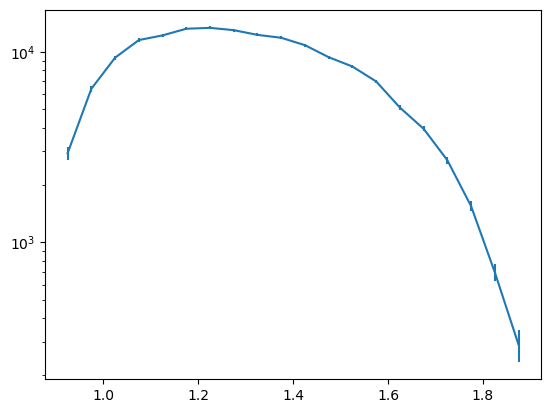

In [13]:
plt.errorbar(c11_erec[carbon_mask], c11_data[carbon_mask], yerr=c11_err[carbon_mask])
plt.semilogy()

# Fit to model


[False  True  True  True False  True  True  True  True  True  True  True]
[0.4555775 0.602833  0.778038  1.03198   1.2107155 1.425145  2.222869
 5.070018  6.295492  7.82888   9.23017   9.94611  ]
[2.222869]
[1.00129234]
[0.8915411  0.91062387 0.93178204 0.95553704 0.96625339 0.97545859
 0.99949146 1.02424606 1.02699706 1.02606553 1.02671524 1.02326235]
[0.89039041 0.90944855 0.93057941 0.95430375 0.96500627 0.97419959
 0.99820144 1.02292409 1.02567154 1.02474121 1.02539008 1.02194165]
[1.022 0.662 0.835 2.5   1.461 2.224 4.95  6.13  7.63  8.99  9.72 ]
[0.0353 0.0432 0.0385 0.0228 0.0297 0.0251 0.0181 0.0151 0.0158 0.0143
 0.0096]
[0.00104 0.0028  0.00241 0.00084 0.00137 0.00093 0.0019  0.00103 0.00168
 0.00233 0.00214]
['Ge68' 'Cs137' 'Mn54' 'Ge68_1.08' 'Co60' 'K40' 'nH' 'nC' '16O' 'nFe'
 'nNi' 'nCr']
[0.0024819  0.00374718 0.00365702 0.01016137 0.00280251 0.0031043
 0.00238722 0.00650665 0.00472379 0.0104048  0.02069329 0.02062867]


<ErrorbarContainer object of 3 artists>

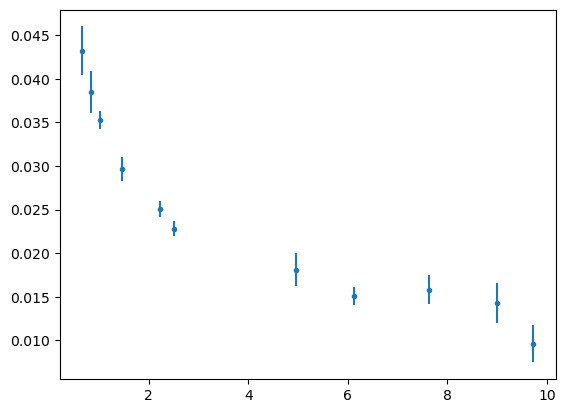

In [9]:
print()
#andrea = pd.read_csv('./NN_data.txt', sep=r"\s+")
#andrea = pd.read_csv('./results_OMILREC_ReProdB_MM_v1.txt', sep=r"\s+", index_col=False)
#andrea = pd.read_csv('./results_OMILREC_Nov09.txt', sep=r"\s+", index_col=False)
andrea = pd.read_csv('./results_CalibGammas_11Nov.txt', sep=r"\s+", index_col=False)

uncertainties = [
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.8,
    0.8
]
evis_array = andrea['en_NL'].to_numpy()
energy_array = andrea['en'].to_numpy()
gamma_array = andrea['mu_corr'].to_numpy()
sigma_array = andrea['resolution'].to_numpy()
err_sigma = andrea['err_resolution'].to_numpy()
single_gamma = andrea['single_gamma'].to_numpy()
source = andrea['Source'].to_numpy()
err_mean = andrea['err_mean_L'].to_numpy()
nh_mask = source == 'nH'
nc_mask = source == 'nC'
factor = gamma_array[nh_mask] / 2.22
print(single_gamma)
gamma_array[~single_gamma] /= 2
print(gamma_array)
err_mean[~single_gamma] /= 2
print(gamma_array[nh_mask])
print(factor)
num = gamma_array / evis_array
print(num)
num /= factor
energy_array = np.delete(energy_array, 3)
sigma_array = np.delete(sigma_array, 3)
err_sigma = np.delete(err_sigma, 3)
uncertainties = np.array(uncertainties )
jerr = np.sqrt( (err_mean/gamma_array)**2 + (err_mean[nh_mask]/gamma_array[nh_mask]) ** 2) * num 
#jerr = np.sqrt( (uncertainties / 100) ** 2 + (uncertainties[nh_mask] / 100) ** 2) * num


print(num)
print(energy_array)
print(sigma_array)
print(err_sigma)

print(source)
print(jerr)
#plt.errorbar(evis_array, num, jerr, ls='none', marker='.')
plt.errorbar(energy_array, sigma_array, yerr=err_sigma, ls='none', marker='.')
#plt.plot(np.linspace(min(energy_array), max(energy_array), 1000), nl.juno_resolution(np.linspace(min(energy_array), max(energy_array), 1000), fit=True))
#plt.plot(energy_array, c)

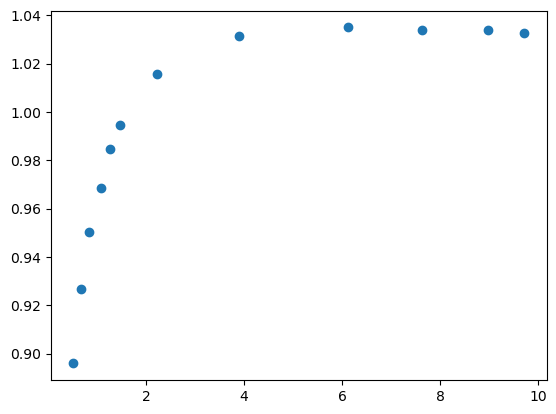

In [22]:
gamma_test = nl.scint_model(E_plot[0:12], *popt[0:3], popt[7])
plt.scatter(E_plot[0:12], gamma_test)

In [10]:
rho = 0.859
from GEPRiS import GEPRiS
nl = GEPRiS(rho, './inputs/')

In [11]:

evis_array[nc_mask] = 3.9
#p0 = [1.073, 16.11e-3, 0.223, 0.033, 0.009, 0.001, 0.0, 1.111e-3, 2.5491, 2.81066, 0.13073, 22.9911]   
p0 = [1.073, 12.11e-3, 0.77, 0.033, 0.009, 0.006, 0.0, 1.111e-3, 1.5491, 3.31066, 0.13073, 400.3212]   

# initial guess for A, kB, fC, a, b, bp, c, alpha,  n_ibd, N_b12, N_n12, N_c11
#p0 = [1.013, 16.11e-3, 0.443, 1.22, 13.15, 3.11] # Milano
#p0 = [1.13, 17.11e-3, 0.443, 1.22, 14.15, 3.11] # IHEP
#p0 = [1.014, 13.21e-3]   # initial guess for A, kB, alpha, tau, kC, v_gamma


bounds = [
    (0.9, 1.5),      # A
    (1e-4, 1e-1),   # kB
    (0, 1.0),     #fC
    (0, 1),      # a
    (0, 1),   # b
    (0, 1),   # bp
    (0, 1.0),     #c
    (0, 3e-3),     #alpha / kI
    (0,10), # n_ibd
    (0, 5000.0),     #N_b12
    (0, 1000.0),     #N_n12
    (2, 1000.0)      #N_c11
]

print('Running Gamma + Resol. + 12B + 11C + nH + Inst. fit')
popt, perr, pcov, chis, ndf = nl.fit_reso(evis_array, num, jerr,
                                     energy_array, sigma_array, err_sigma, 
                                          ibd_data, ibd_err, ibd_centers,
                                     b12_data[data_mask], b12_err[data_mask], b12_erec[data_mask],
                                     c11_data[carbon_mask], c11_err[carbon_mask], c11_erec[carbon_mask], 
                                     p0, bounds)
print(np.sum(chis/ndf))

Running Gamma + Resol. + 12B + 11C + nH + Inst. fit


/Users/robertomandujano/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2093: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/robertomandujano/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2093: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/robertomandujano/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2093: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/robertomandujano/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2093: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/Users/robertomandujano/note/irvine_nl.py:308: RuntimeWarning: invalid value encountered in divide
  spectrum /= np.sum(spectrum)
/Users/robertomandujano/note/irvine_nl

8.964950636629585


In [23]:
print(popt)
print(perr)
#print(pcov)
#print(chis)
#print(ndf)

[1.06312489e+00 1.14933290e-02 0.00000000e+00 4.52281626e-02
 0.00000000e+00 0.00000000e+00 2.46775289e-08 0.00000000e+00
 4.53137695e+00 2.93128141e+00 1.23233348e-01 4.25658934e+02]
[2.33375562e-03 2.74022430e-04 2.54296572e-02 4.04304215e-04
 9.33236706e-04 1.27604858e-03 1.16509174e-03 3.67472493e-04
 5.23390121e-02 1.70950056e-02 8.36740047e-03 2.45447130e+00]


# Make curves and estimate uncertainty bands

In [12]:
## produce models with monte-carlo estimated uncertainty bands mkay

import matplotlib.pyplot as plt
import matplotlib.cm as cm
cmap = cm.get_cmap('plasma')
evis_array[nc_mask] = 3.9
# Compare model vs data
#E_plot = evis_array
E_plot = np.concatenate([evis_array, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]])
n_samples = int(1e3)
#y_fit = nl.scint_model(E_plot, *popt[0:3])
#y_int = interp1d(E_plot, y_fit, kind='quadratic', fill_value='extrapolate')
yx = np.linspace(1e-1, 10, n_samples) 
print(popt)
print(len(popt))
#make cosmo and neutrino curves
print('Estimating nH Bands...')
f_ibd_pred, ibd_sigma = nl.cosmo_with_uncertainty(nl.nH_prediction, *popt, target_centers=ibd_centers,
                                                                          cov=pcov, n_samples=500)
print('Estimating 11C Bands...')
f_c11_pred, f_c11_bins, c11_sigma = nl.cosmo_with_uncertainty(nl.C11_prediction, *popt, target_centers=c11_erec[carbon_mask], 
                                                              cov=pcov, n_samples=500, perturb_beta=True)

print('Estimating 12B Bands...')
f_b12_pred, f_n12_pred, f_b12_bins, b12_sigma = nl.cosmo_with_uncertainty(nl.B12_prediction, *popt, target_centers=b12_erec[data_mask],
                                                                          cov=pcov, n_samples=500, perturb_beta=True)


/var/folders/tt/rslnzb850cj2l2p5zw4npt300000gn/T/ipykernel_22000/3108905513.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('plasma')


[1.08464412e+00 1.63844866e-02 5.67250218e-03 3.51652938e-02
 6.26680583e-03 7.47903379e-03 0.00000000e+00 9.80661835e-04
 2.56691254e+00 3.06307074e+00 8.97833485e-02 4.69261826e+02]
12
Estimating nH Bands...


/Users/robertomandujano/note/irvine_nl.py:500: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  params = rng.multivariate_normal([A, kB_gcm2, fC, a, b, bp, c, alpha, n_ibd, n_b12, n_n12, n_c11], cov, size=n_samples)


Estimating 11C Bands...


/Users/robertomandujano/note/irvine_nl.py:500: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  params = rng.multivariate_normal([A, kB_gcm2, fC, a, b, bp, c, alpha, n_ibd, n_b12, n_n12, n_c11], cov, size=n_samples)


Estimating 12B Bands...


/Users/robertomandujano/note/irvine_nl.py:500: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  params = rng.multivariate_normal([A, kB_gcm2, fC, a, b, bp, c, alpha, n_ibd, n_b12, n_n12, n_c11], cov, size=n_samples)


In [13]:
#make beta and gamma curves
print(perr)
print('Estimating electron bands...')
elec_nl, elec_sigma = nl.beta_mc_uncertainty(
    yx, *popt[0:3], popt[7], *perr[0:3],perr[7], is_pos=False, n_samples=500
)
print('Estimating positron bands...')
pos_nl, pos_sigma = nl.beta_mc_uncertainty(
    yx, *popt[0:3], popt[7], *perr[0:3], perr[7], is_pos=True,  n_samples=500
)
print('Estimating gamma bands...')
y_fit, gamma_sigma = nl.gamma_mc_uncertainty(
    E_plot, *popt[0:3], popt[7], *perr[0:3], perr[7]
)

e_positron = yx + 2 * 0.511

[4.47112362e-04 1.23531779e-04 3.70922422e-04            nan
 1.28086337e-03 1.21083902e-03 2.62295851e-04 3.70728679e-04
 5.08511587e-02 1.74357064e-02 7.78840667e-03 2.44066306e+00]
Estimating electron bands...
Estimating positron bands...
Estimating gamma bands...


In [17]:
#make predictions with no bands
import matplotlib.cm as cm
cmap = cm.get_cmap('plasma')
E_plot = np.concatenate([evis_array, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]])
n_samples = int(1e3)
#y_fit = nl.scint_model(E_plot, *popt[0:3])
#y_int = interp1d(E_plot, y_fit, kind='quadratic', fill_value='extrapolate')
yx = np.linspace(1e-1, 10, n_samples)
print('Estimating nH Bands...')
f_ibd_pred = nl.nH_prediction(ibd_centers, *popt[0:8])

print('Estimating 11C Bands...')
f_c11_pred, f_c11_bins = nl.C11_prediction(c11_erec[carbon_mask],*popt[0:8]) 

print('Estimating 12B Bands...')
f_b12_pred, f_n12_pred, f_b12_bins = nl.B12_prediction(b12_erec[data_mask], *popt[0:8])

print('Estimating electron bands...')
elec_nl = nl.beta_scint(
    yx, *popt[0:3], popt[7], is_pos=False
)
print('Estimating positron bands...')
pos_nl = nl.beta_scint(
    yx, *popt[0:3], popt[7], is_pos=True
)
print('Estimating gamma bands...')
y_fit = nl.scint_model(
    E_plot, *popt[0:3], popt[7])
e_positron = yx + 2 * 0.511

/var/folders/tt/rslnzb850cj2l2p5zw4npt300000gn/T/ipykernel_55682/3548611553.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('plasma')


Estimating nH Bands...
Estimating 11C Bands...
Estimating 12B Bands...
Estimating electron bands...
Estimating positron bands...
Estimating gamma bands...


# Plotting (very long)

27
27


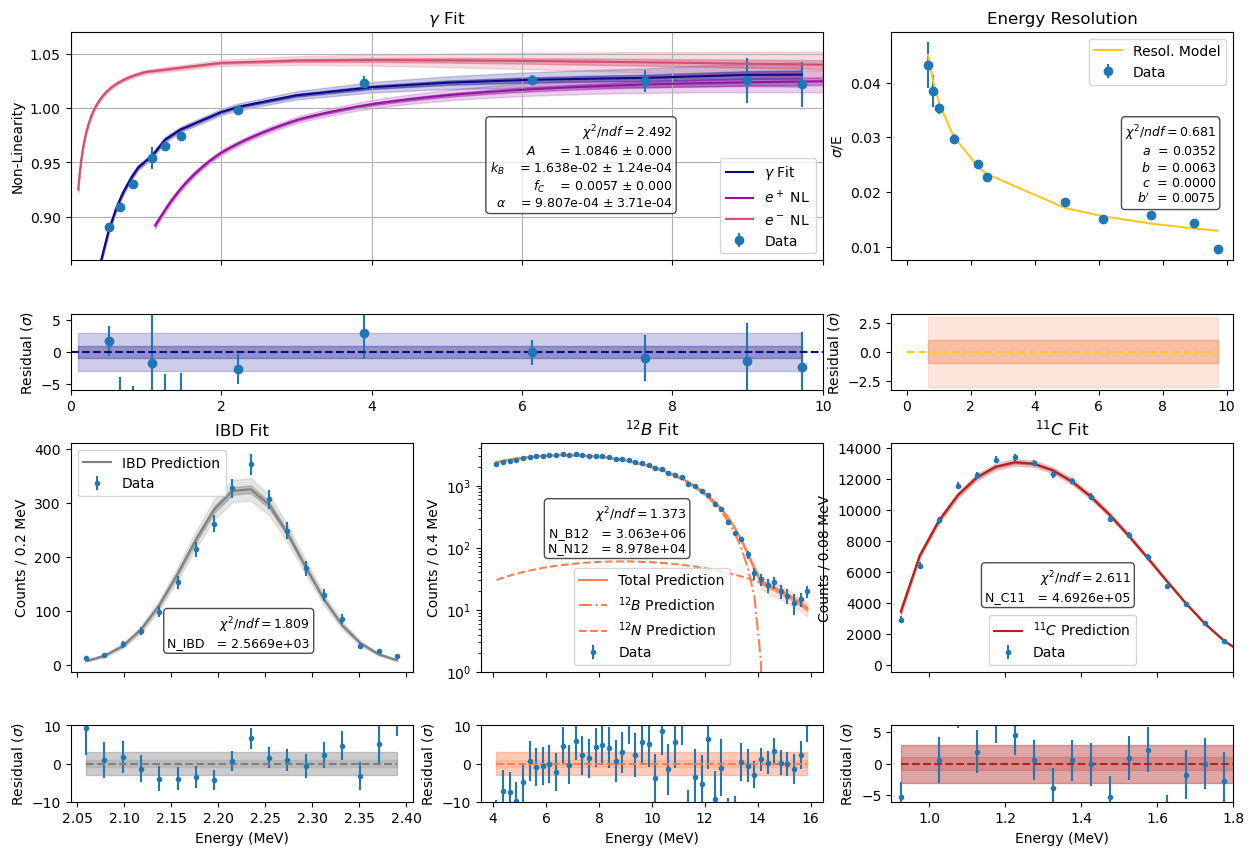

In [15]:
from matplotlib.gridspec import GridSpec
bands = True
#fig, axs = plt.subplots(2,3, figsize=(20, 6), height_ratios=[1,1])
#fig, axs = plt.subplots(4, 2, figsize=(10, 15), height_ratios=[2, 1, 2, 1])
fig = plt.figure(figsize=(15, 10))

# 4 rows, 3 cols -- top will use only first 2 cols, bottom will use all 3
gs = GridSpec(nrows=4, ncols=3, figure=fig,
              height_ratios=[3, 1, 3, 1],
              hspace=0.35, wspace=0.2)
# --- Top row (main + residual) centered across middle columns ---
ax_gamma = fig.add_subplot(gs[0, 0:2])  # spans columns 0–1
ax_reso = fig.add_subplot(gs[0, 2])  # spans columns 1–2
# sharex between their residuals below
ax_rg = fig.add_subplot(gs[1, 0:2], sharex=ax_gamma)
ax_rr = fig.add_subplot(gs[1, 2], sharex=ax_reso)

# --- Bottom row (main + residual), 3 across ---
ax_ibd = fig.add_subplot(gs[2, 0])
ax_b12 = fig.add_subplot(gs[2, 1])
ax_c11 = fig.add_subplot(gs[2, 2])
ax_ribd = fig.add_subplot(gs[3, 0], sharex=ax_ibd)
ax_rb12 = fig.add_subplot(gs[3, 1], sharex=ax_b12)
ax_rc11 = fig.add_subplot(gs[3, 2], sharex=ax_c11)

# Make main and residual plots share x-axis
#for main, res in zip(main_ax, res_ax):
 #   res.sharex(main)
# Hide x tick labels on main axes
for a in (ax_gamma, ax_reso, ax_ibd, ax_b12, ax_c11):
    plt.setp(a.get_xticklabels(), visible=False)

##### Gamma #########
sorted_indices = np.argsort(E_plot)
print(len(E_plot))
print(len(y_fit))
ax_gamma.errorbar(evis_array, num, yerr=jerr, fmt='o', label="Data")
ax_gamma.plot(E_plot[sorted_indices], y_fit[sorted_indices], '-', label=r"$\gamma$ Fit", color=cmap(0))
#plt.plot(evis_array, y_fit, '-', label="Gamma Fit")
ax_gamma.plot(e_positron, pos_nl, '-', label=r"$e^+$ NL", color=cmap(0.32))
ax_gamma.plot(yx, elec_nl, '-', label=r"$e^-$ NL", color=cmap(0.53))
ax_gamma.set_title(r"$\gamma$ Fit")
#ax.set_xlabel("Gamma Energy (MeV)")
ax_gamma.set_ylabel("Non-Linearity")
ax_gamma.grid(True)
ax_gamma.set_xlim(0,10)

#uncertainty bands
if bands:
    ax_gamma.fill_between(
        E_plot[sorted_indices],
        y_fit[sorted_indices]  - 3*gamma_sigma[sorted_indices] ,
        y_fit[sorted_indices]  + 3*gamma_sigma[sorted_indices] ,
        color=cmap(0),
        alpha=0.2
    )
    
    ax_gamma.fill_between(
        E_plot[sorted_indices],
        y_fit[sorted_indices] - gamma_sigma[sorted_indices] ,
        y_fit[sorted_indices]  + gamma_sigma[sorted_indices] ,
        color=cmap(0),
        alpha=0.4
    )
    
    ax_gamma.fill_between(
        yx,
        elec_nl - 3*elec_sigma,
        elec_nl + 3*elec_sigma,
        color=cmap(0.53),
        alpha=0.2
    )
    
    ax_gamma.fill_between(
        yx,
        elec_nl - elec_sigma,
        elec_nl + elec_sigma,
        color=cmap(0.53),
        alpha=0.4
    )
    
    
    ax_gamma.fill_between(
        e_positron,
        pos_nl - 3*pos_sigma,
        pos_nl + 3*pos_sigma,
        color=cmap(0.32),
        alpha=0.2
    )
    
    ax_gamma.fill_between(
        e_positron,
        pos_nl - pos_sigma,
        pos_nl + pos_sigma,
        color=cmap(0.32),
        alpha=0.4
    )
    
    #plot residuals in subplo
    
    
    ax_rg.fill_between(
        E_plot[sorted_indices],
        -3,
        3,
        color=cmap(0),
        alpha=0.2
    )
    
    ax_rg.fill_between(
        E_plot[sorted_indices],
        -1,
        1,
        color=cmap(0),
        alpha=0.3
    )
    res_err = jerr / gamma_sigma[0:12]
    res_spec = (num - y_fit[0:12])/gamma_sigma[0:12]
    
    ax_rg.errorbar(evis_array, res_spec , yerr=res_err, ls='none', marker='o')
    ax_rg.plot([0, 10], [0,0], ls='--', color=cmap(0))
    ax_rg.set_ylabel(r"Residual ($\sigma$)")
    #ax_rg.set_xlabel(r"$\gamma$ Energy (MeV)")
    ax_rg.set_ylim(-6,6)
    
ax_gamma.legend()
ax_gamma.set_ylim(0.86,1.07)

# gamma text box
fit_text_0 = (
    r"$\chi^2 / ndf = " f"{np.abs(chis[0]/ndf[0]):.3f}$" + "\n"
    f"$A$      = {popt[0]:.4f} $\\pm$ {perr[0]:.3f}\n"
    f"$k_B$    = {popt[1]:.3e} $\\pm$ {perr[1]:.2e}\n"
    f"$f_C$    = {popt[2]:.4f} $\\pm$ {perr[2]:.3f}\n"
    f"$ \\alpha $    = {popt[7]:.3e} $\\pm$ {perr[7]:.2e}"
)

ax_gamma.text(
    0.8, 0.6, fit_text_0,
    transform=ax_gamma.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)

#####  RESOLUTION ######

sigma_sort = np.argsort(energy_array)
data_reso = sigma_array
ereso = nl.juno_resolution(energy_array, a=popt[3], b=popt[4], c=popt[5], fit=True)
#ereso = nl.juno_resolution(energy_array, a=0.033, b=0.009, c=0, fit=True)

reso_err = err_sigma/energy_array
ax_reso.errorbar(energy_array, data_reso, yerr=reso_err, fmt='o', label="Data")
ax_reso.plot(energy_array[sigma_sort], ereso[sigma_sort], label="Resol. Model", color=cmap(0.88))
ax_reso.set_title("Energy Resolution")
ax_reso.set_ylabel(r"$\sigma$/E")
sigma_sigma = nl.juno_reso_error(energy_array, *popt[3:6], *perr[3:6])
resid_err = reso_err / sigma_sigma

#ax_rr.set_xlabel(r"$\gamma$ Energy (MeV)")
#ax_rr.set_ylim(-6,6)

if bands:
    
    ax_reso.fill_between(
        energy_array[sigma_sort],
        ereso[sigma_sort]  - 3*sigma_sigma[sigma_sort] ,
        ereso[sigma_sort]  + 3*sigma_sigma[sigma_sort] ,
        color=cmap(0.7),
        alpha=0.2
    )
    
    ax_reso.fill_between(
        energy_array[sigma_sort],
        ereso[sigma_sort]  - 1*sigma_sigma[sigma_sort] ,
        ereso[sigma_sort]  + 1*sigma_sigma[sigma_sort] ,
        color=cmap(0.7),
        alpha=0.4
    )
    
    #plot residuals in subplot
    
    ax_rr.fill_between(
        energy_array[sigma_sort],
        -3 ,
        3 ,
        color=cmap(0.7),
        alpha=0.2
    )
    
    ax_rr.fill_between(
        energy_array[sigma_sort],
        -1 ,
        1,
        color=cmap(0.7),
        alpha=0.4
    )
ax_rr.errorbar(energy_array, (data_reso - ereso)/sigma_sigma , yerr=resid_err, ls='none', marker='o')
ax_rr.plot([0, max(energy_array)], [0,0], ls='--', color=cmap(0.88))
ax_rr.set_ylabel(r"Residual ($\sigma$)")   
fit_text_res = (
    r"$\chi^2 / ndf = " f"{np.abs(chis[-1]/ndf[-1]):.3f}$" + "\n"
    f"$a$  = {popt[3]:.4f}\n"
    f"$b$  = {popt[4]:.4f}\n"
    f"$c$  = {popt[6]:.4f}\n"
    f"$b'$  = {popt[5]:.4f}"
)

ax_reso.text(
    0.95, 0.6, fit_text_res,
    transform=ax_reso.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)
ax_reso.legend()
###### IBD #######
ax_ibd.plot(ibd_centers, f_ibd_pred*popt[-4], color='gray', label="IBD Prediction")
ax_ibd.errorbar(ibd_centers , ibd_data, yerr=ibd_err, ls='none', marker='.', label=r"Data")
ax_ibd.set_ylabel('Counts / 0.2 MeV')

if bands:
    ax_ibd.fill_between(
        ibd_centers,
        f_ibd_pred*popt[-4]  - 3*ibd_sigma,
        f_ibd_pred*popt[-4]  + 3*ibd_sigma ,
        color='gray',
        alpha=0.2
    )
    
    ax_ibd.fill_between(
        ibd_centers,
        f_ibd_pred*popt[-4] - ibd_sigma ,
        f_ibd_pred*popt[-4]   + ibd_sigma ,
        color='gray',
        alpha=0.4
    )

    #ax_ribd.set_xlim(0.9,1.8)
    
    ax_ribd.fill_between(
        ibd_centers,
        -1,
        1,
        color='gray',
        alpha=0.2
    )

    ax_ribd.fill_between(
        ibd_centers,
        -3,
        3,
        color='gray',
        alpha=0.4
    )
    ax_ribd.errorbar(ibd_centers, ((ibd_data - f_ibd_pred*popt[-4])/ibd_sigma), 
                       yerr=ibd_err/ibd_sigma,  ls='none' , marker='.')
    ax_ribd.plot([min(ibd_centers), max(ibd_centers)], [0,0], ls='--', color='gray')
    ax_ribd.set_ylabel(r"Residual ($\sigma$)")
    ax_ribd.set_xlabel("Energy (MeV)")
    ax_ribd.set_ylim(-10,10)
ax_ibd.legend()
ax_ibd.set_title(r"IBD Fit")

# ibd text box
fit_text_ibd = (
    r"$\chi^2 / ndf = " f"{chis[1]/ndf[1]:.3f}$" + "\n"
    f"N_IBD   = {popt[-4]*1000:.4e}"
)

ax_ibd.text(
    0.7, 0.25, fit_text_ibd,
    transform=ax_ibd.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)




##### 12B #########
#f_b12_pred, f_n12_pred, f_b12_bins  = nl.B12_prediction(*popt[0:3] ,b12_erec[data_mask])
#total_spec = f_b12_pred*popt[6] + f_n12_pred*popt[7]
total_spec = f_b12_pred*popt[9] + f_n12_pred*popt[10]

ax_b12.plot(f_b12_bins, total_spec , color='coral', label=r"Total Prediction")
ax_b12.plot(f_b12_bins, f_b12_pred*popt[9] , color='coral', ls='-.', label=r"$^{12}B$ Prediction")
ax_b12.plot(f_b12_bins, f_n12_pred*popt[10] , color='coral', ls='--', label=r"$^{12}N$ Prediction")
ax_b12.errorbar(b12_erec[data_mask],b12_data[data_mask], yerr=b12_err[data_mask], ls='none', marker='.', label='Data')
ax_b12.semilogy()
ax_b12.set_ylabel('Counts / 0.4 MeV')


if bands:
#uncertainty bands
    ax_b12.fill_between(
        f_b12_bins,
        total_spec  - 3*b12_sigma,
        total_spec  + 3*b12_sigma ,
        color='coral',
        alpha=0.2
    )
    
    ax_b12.fill_between(
        f_b12_bins,
        total_spec  - b12_sigma ,
        total_spec   + b12_sigma ,
        color='coral',
        alpha=0.5
    )
    
    ax_rb12.fill_between(
        f_b12_bins,
        -1,
        1,
        color='coral',
        alpha=0.2
    )
    
    ax_rb12.fill_between(
        f_b12_bins,
        -3,
        3,
        color='coral',
        alpha=0.4
    )
    ax_rb12.errorbar(b12_erec[data_mask], ((b12_data[data_mask] - total_spec)/b12_sigma) , yerr = b12_err[data_mask]/b12_sigma,  ls='none', marker = '.' )
    ax_rb12.plot([min(b12_erec[data_mask]), max(b12_erec[data_mask])], [0,0], ls='--', color='coral')
    ax_rb12.set_ylabel(r"Residual ($\sigma$)")
    ax_rb12.set_xlabel("Energy (MeV)")
    ax_rb12.set_ylim(-10,10)

ax_b12.legend()
ax_b12.set_title(r"$^{12}B$ Fit")

# boron text box
fit_text_1 = (
    r"$\chi^2 / ndf = " f"{chis[2]/ndf[2]:.3f}$" + "\n"
    f"N_B12   = {popt[9]*1000000:.3e}\n"
    f"N_N12   = {popt[10]*1000000:.3e}"
)

ax_b12.text(
    0.6, 0.73, fit_text_1,
    transform=ax_b12.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)


##### 11C #########
#f_c11_pred, f_c11_bins  = nl.C11_prediction(*popt[0:3], c11_erec[carbon_mask])
ax_c11.plot(f_c11_bins, f_c11_pred*popt[-1], color='firebrick', label=r"$^{11}C$ Prediction")
ax_c11.errorbar(c11_erec[carbon_mask] ,c11_data[carbon_mask], yerr=c11_err[carbon_mask], ls='none', marker='.', label=r"Data")
ax_c11.set_ylabel('Counts / 0.08 MeV')


if bands:
    ax_c11.fill_between(
        f_c11_bins,
        f_c11_pred*popt[-1]  - 3*c11_sigma,
        f_c11_pred*popt[-1]  + 3*c11_sigma ,
        color='firebrick',
        alpha=0.2
    )
    
    ax_c11.fill_between(
        f_c11_bins,
        f_c11_pred*popt[-1] - c11_sigma ,
        f_c11_pred*popt[-1]   + c11_sigma ,
        color='firebrick',
        alpha=0.4
    )
    
    ax_rc11.fill_between(
        f_c11_bins,
        -1*c11_sigma / c11_sigma,
        1*c11_sigma / c11_sigma,
        color='firebrick',
        alpha=0.2
    )
    
    ax_rc11.fill_between(
        f_c11_bins,
        -3*c11_sigma / c11_sigma,
        3 *c11_sigma / c11_sigma,
        color='firebrick',
        alpha=0.4
    )
    ax_rc11.errorbar(c11_erec[carbon_mask], ((c11_data[carbon_mask] - f_c11_pred*popt[-1])/c11_sigma), 
                 yerr=c11_err[carbon_mask]/c11_sigma,  ls='none' , marker='.')
    ax_rc11.plot([min(c11_erec[carbon_mask]), max(c11_erec[carbon_mask])], [0,0], ls='--', color='firebrick')
    ax_rc11.set_ylabel(r"Residual ($\sigma$)")
    ax_rc11.set_xlabel("Energy (MeV)")
    ax_rc11.set_ylim(-6,6)
    ax_rc11.set_xlim(0.9,1.8)
    
    ax_c11.legend()
    ax_c11.set_title(r"$^{11}C$ Fit")

# carbon text box
fit_text_2 = (
    r"$\chi^2 / ndf = " f"{chis[3]/ndf[3]:.3f}$" + "\n"
    f"N_C11   = {popt[-1]*1000:.4e}"
)

ax_c11.text(
    0.7, 0.45, fit_text_2,
    transform=ax_c11.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)

plt.savefig('NL_JUNO_Irvine_IBD+MilanoB12+C11_RP25C_dec11.pdf', dpi=200)
plt.show()

0.1536587989430232
3


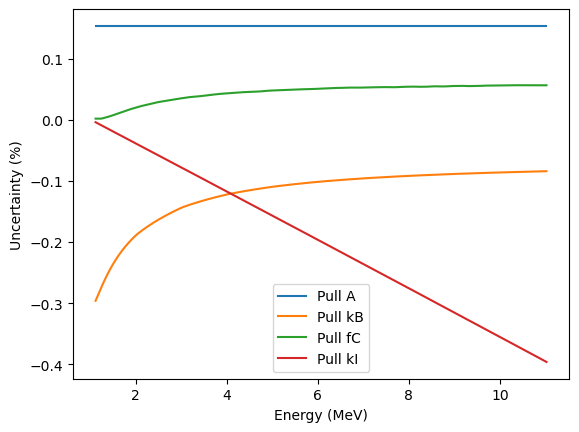

In [95]:
## pulls = nl.make_pulls(popt[0:3], perr[0:3], pcov[0:3, 0:3], n_draws=10000)
# nominal parameters

# define ±1σ variations (based on your calibration or ad hoc 1–5%)
print(100*perr[0]/popt[0])
dA = perr[0]
dkB = perr[1]
dfC = perr[2]
dkI = perr[7]

#nominal positron
print(len(popt[0:3]))
nl_nom = nl.beta_scint(yx, *popt[0:3], popt[7], is_pos=True)

nl_A = [nl.beta_scint(yx, popt[0]+dA, popt[1], popt[2], popt[7], is_pos=True), nl.beta_scint(yx, popt[0]-dA, popt[1], popt[2], popt[7], is_pos=True)]
nl_kB = [nl.beta_scint(yx, popt[0], popt[1]+dkB, popt[2], popt[7], is_pos=True), nl.beta_scint(yx, popt[0], popt[1]-dkB, popt[2], popt[7], is_pos=True)]
nl_fC = [nl.beta_scint(yx, popt[0], popt[1], popt[2]+dfC, popt[7], is_pos=True), nl.beta_scint(yx, popt[0], popt[1], popt[2]-dfC, popt[7], is_pos=True)]
nl_kI = [nl.beta_scint(yx, popt[0], popt[1], popt[2], popt[7]+dkI, is_pos=True), nl.beta_scint(yx, popt[0], popt[1], popt[2], popt[7]-dkI, is_pos=True)]




pulls = []
nls = [np.array(nl_A), np.array(nl_kB), np.array(nl_fC), np.array(nl_kI)]
plabel = ['A', 'kB', 'fC', 'kI']
for i, nlp in enumerate(nls):
    pulls.append( 0.5*(nlp[0] - nlp[1]) /nl_nom)
    plt.plot(e_positron, 100*pulls[i], label='Pull '+str(plabel[i]))
plt.legend()
plt.ylabel('Uncertainty (%)')
plt.xlabel('Energy (MeV)')
nl_plus = 100*(pulls[1] + pulls[2] + pulls[3])
nl_minus = 100*(-pulls[1] - pulls[2] - pulls[3])
#plt.ylim(-0.001, 0.0025)
#plt.fill_between(e_positron, nl_minus, nl_plus, color='gray', alpha=0.2, label='±1σ total')
#plt.savefig('pulls_nov12.png')

In [63]:
import numpy as np
import itertools
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

# -----------------------------
# 2. Brute-force uncertainty exploration
# -----------------------------
def generate_curves(T, params_nominal, cov_matrix, n_samples):
    """
    Generate curves within 1σ hyper-ellipsoid based on χ².
    """
    rng = np.random.default_rng(42)
    L = np.linalg.cholesky(cov_matrix)
    param_samples = []
    curves = []
    chi2_vals = []

    for _ in range(n_samples):
        delta = rng.normal(size=len(params_nominal))
        trial = params_nominal + L @ delta
        chi2 = np.dot(delta, delta)
        if chi2 <= 1.0:  # within 1σ hypercontour
            curve = nl.beta_scint(T, *trial, is_pos=True)
            param_samples.append(trial)
            curves.append(curve)
            chi2_vals.append(chi2)

    return np.array(param_samples), np.array(curves), np.array(chi2_vals)

# -----------------------------
# 3. Brute-force base curve selection
# -----------------------------
def brute_force_base_curves(curves):
    n_curves = len(curves)
    indices = range(n_curves)
    best_combo = None
    best_total_chi2 = np.inf

    for combo in itertools.combinations(indices, 4):
        base_curves = curves[list(combo)]
        remaining = [i for i in indices if i not in combo]

        total_chi2 = 0
        for i in remaining:
            target = curves[i]
            A = base_curves.T
            coeffs, residuals, _, _ = np.linalg.lstsq(A, target, rcond=None)
            fit = np.dot(coeffs, base_curves)
            total_chi2 += np.sum((target - fit) ** 2)

        if total_chi2 < best_total_chi2:
            best_total_chi2 = total_chi2
            best_combo = combo

    return best_combo, best_total_chi2

# -----------------------------
# Example usage (replace with your real functions)
# -----------------------------

# Parameters
params_nominal = np.array([*popt[0:3], popt[7]])
cov_matrix = np.diag([*perr[0:3], perr[7]]) ** 2

# Generate and evaluate
pull_params, pull_curves, p_chi2s = generate_curves(
    yx, params_nominal, cov_matrix, 250)


best_combo, best_chi2 = brute_force_base_curves(pull_curves)
print("Best 4 base curve indices:", best_combo)
print("Total χ²:", best_chi2)


Best 4 base curve indices: (7, 19, 22, 23)
Total χ²: 1.1042806084076307e-14


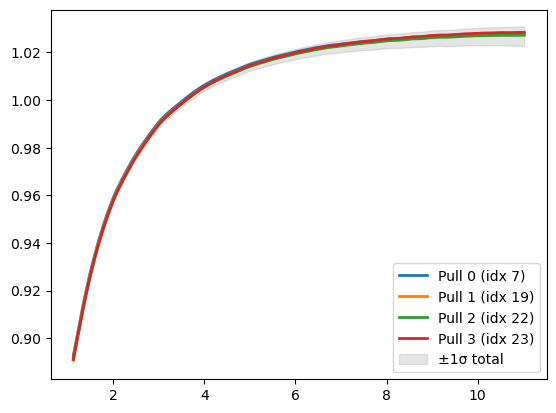

In [64]:
for j, idx in enumerate(best_combo):
        plt.plot(e_positron, pull_curves[best_combo[j]], lw=2, label=f'Pull {j} (idx {idx})')
plt.fill_between(e_positron, pos_nl-pos_sigma, pos_nl+pos_sigma, color='gray', alpha=0.2, label='±1σ total')
plt.legend()
plt.savefig('pulls_nov14.png')

In [65]:
bin_width = yx[1] - yx[0] 
# The edges will be the centers +/- half the bin width
e_positron = np.array(e_positron)
pull_edges = np.concatenate([
    e_positron - bin_width / 2, # All lower edges
    [e_positron[-1] + bin_width / 2] # The single final upper edge
])

# --- 3. Define the output file and histogram name ---
output_filename = "Irvine_NL_inputs_nov14_2025.root"
with uproot.recreate(output_filename) as file:
    for i in range(4):
        histogram_name= "positronScintNLpull" +str(i)
        file[histogram_name] = (np.array(pull_curves[best_combo[i]]), pull_edges)
    
    file["positronScintNL"] = (np.array(pos_nl), pull_edges)


In [30]:
# Stack arrays column-wise
gdata = np.column_stack((E_plot, y_fit, gamma_sigma))
edata = np.column_stack((yx, elec_nl, elec_sigma))
pdata = np.column_stack((e_positron, pos_nl, pos_sigma))

# Save as CSV
np.savetxt("Irvine_beta-_nl_B12+C11+IBD_nov15.csv", edata, delimiter=",", header="E_MeV,NL,sigma", comments="")
np.savetxt("Irvine_gamma_nl_B12+C11+IBD_nov15.csv", gdata, delimiter=",", header="E_MeV,NL,sigma", comments="")
np.savetxt("Irvine_beta+_nl_B12+C11+IBD_nov15.csv", pdata, delimiter=",", header="E_MeV,NL,sigma", comments="")

# Comparisons and funny stuff

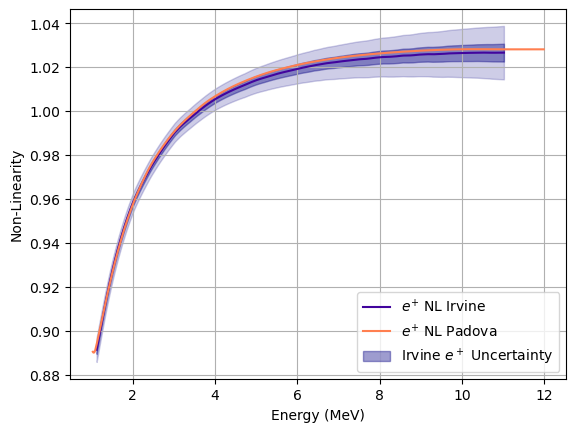

In [33]:
#milano = pd.read_csv('./NL_Repr25B_20251031_v3_nH_sharedLY.csv', sep=',')
with uproot.open('./NL_Repr25C_20251113_Rob.root') as milano:
    graph = milano['nl_positron_LY1']
    x_data = graph.member('fX')
    y_data = graph.member('fY')

#irvine = pd.read_csv('./Irvine_beta+_nl_B12+C11+IBD_nov13.csv', sep=',')
#ihep = pd.read_csv('./IHEP_beta+_nl_B12+C11_nov3.csv', sep=',')

#plt.plot(irvine['E_MeV'], irvine['NL'], color=cmap(0), label='$e^{+}$ NL w/ Irvine $^{12}B$')
plt.plot(e_positron, pos_nl, color=cmap(0.1), label='$e^{+}$ NL Irvine')
#plt.plot(milano['E_MeV'], milano['positron_NL_LY1'], color='coral', label='$e^{+}$ NL Padova')
plt.plot(x_data, y_data, color='coral', label='$e^{+}$ NL Padova')


plt.fill_between(
    e_positron,
    pos_nl - 3*pos_sigma,
    pos_nl + 3*pos_sigma,
    color=cmap(0),
    alpha=0.2
)


plt.fill_between(
    e_positron,
    pos_nl - pos_sigma,
    pos_nl + pos_sigma,
    color=cmap(0),
    alpha=0.4,
    label=r"Irvine $e^+$ Uncertainty"
)


#plt.plot(ihep['E_MeV'], ihep['NL'], color=cmap(0.66), label='$e^{+}$ NL w/ IHEP $^{12}B$')
plt.xlabel('Energy (MeV)')
plt.ylabel('Non-Linearity')
plt.grid(True)
plt.legend()
plt.savefig('NL_beta+_comp_nov14.png')

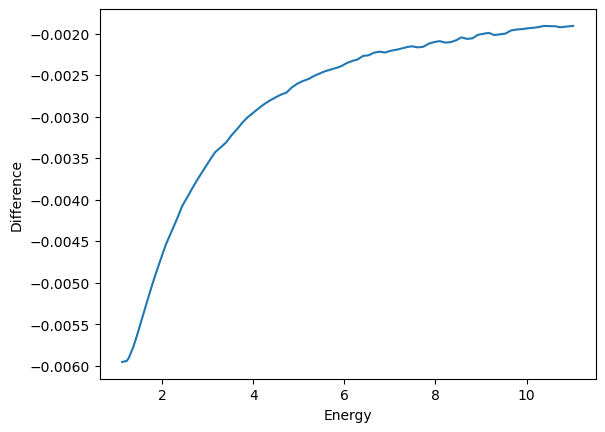

In [74]:
nldiff = milano['NL']- irvine['NL'] 
plt.plot(irvine['E_MeV'], nldiff)
plt.ylabel('Difference')
plt.xlabel('Energy')
plt.savefig('NL_diff_comp_nov10.png')

In [172]:
print("Manual:", 1.03, 12e-3, 0.859, 0.5)
print("From popt:", *popt[0:2], 0.859, popt[2])

Manual: 1.03 0.012 0.859 0.5
From popt: 1.2 0.1111 0.859 0.2


# Comparisons and whatnot

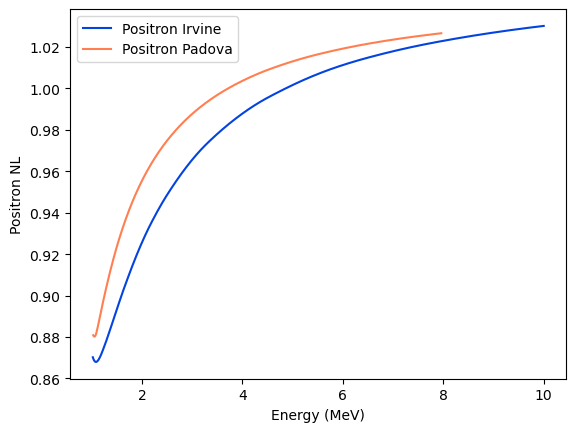

In [133]:
andrea_pos = pd.read_csv('./for_roberto.csv', sep=',')
plt.plot(e_positron, positron_nl, '-', label="Positron Irvine", color='xkcd:blue')
plt.plot(andrea_pos['E_MeV'], andrea_pos['positron'], '-', label="Positron Padova", color='coral')
plt.xlabel('Energy (MeV)')
plt.ylabel('Positron NL')
plt.legend()
plt.savefig('positron_comp_oct27_irvine_nob12.png')

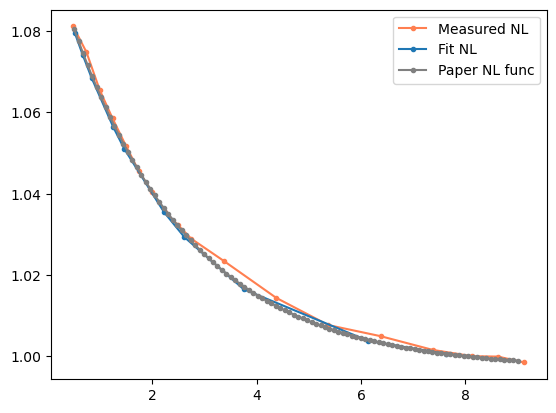

In [185]:
xe = np.linspace(0.5, 9, 100)
#plt.plot(xe, nl(xe), label="Interpolated NL", marker='.', color='skyblue')
plt.plot(enl[:,0], enl[:,1], label="Measured NL", marker='.', color='coral')

#enl[:,0], enl[:,1]
plt.plot(energies, dyb_nl(energies, 8.05, popt[2], popt[3]), marker='.', label="Fit NL")
plt.plot(xe, dyb_nl(xe, 8.05, 0.104, 2.3), marker='.', label="Paper NL func", color='gray')

plt.legend()

In [20]:
branches = [
    {"prob": 0.68, "gammas": [4.945]},        # direct to ground
    {"prob": 0.32, "gammas": [1.261, 3.683]}  # to 3.684 MeV state
]

# Compute totals
E_tot = 0.0
N_gamma = 0.0
for b in branches:
    E_tot += b["prob"] * sum(b["gammas"])
    N_gamma += b["prob"] * len(b["gammas"])

avg_gamma_energy = E_tot / N_gamma

print(f"Total weighted gamma energy = {E_tot:.3f} MeV")
print(f"Total weighted number of gammas = {N_gamma:.3f}")
print(f"Average gamma energy = {avg_gamma_energy:.3f} MeV")

Total weighted gamma energy = 4.945 MeV
Total weighted number of gammas = 1.320
Average gamma energy = 3.746 MeV


In [19]:
with uproot.open('./energymodel_Apr2018_newE.root') as file:
    graph = file['gammaFullNL']
    scint = file['gammaScintNL']
    x_model, y_model = graph.values(axis="both")
    x_scint, y_scint = scint.values(axis="both")
print(x_model)

[ 0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   2.   3.   4.   5.   6.
  7.   8.   9.  10. ]


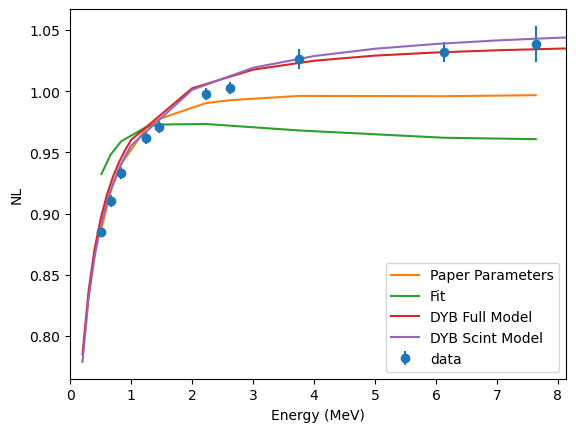

In [199]:
plt.errorbar(energies, data, yerr=errors, fmt='o', label="data")
yex = birks_model(energies, 1.013, 15.8e-3, 0.104, 2.3, 0.019, 0.86, mass_stopping, E_vals, positron, cherenkov)
mex = birks_model(energies, *popt[0:5], 0.86, mass_stopping, E_vals, positron, cherenkov)
plt.plot(energies, yex, label = 'Paper Parameters')
plt.plot(energies, mex, label = 'Fit')
plt.plot(x_model, y_model, label = 'DYB Full Model')
plt.plot(x_scint, y_scint, label = 'DYB Scint Model')
plt.legend()
plt.xlim(0,np.max(energies)+0.5)
plt.xlabel('Energy (MeV)')
plt.ylabel('NL')
plt.savefig('Full_model_comp.pdf')

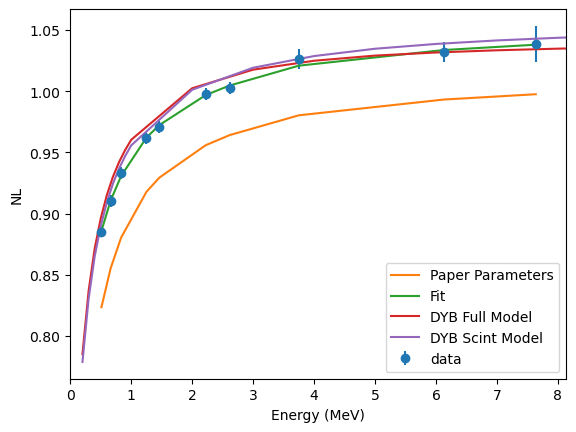

In [118]:
plt.errorbar(energies, data, yerr=errors, fmt='o', label="data")
yex = scint_model(energies, 1.013, 15.8e-3, 0.019, 0.86, mass_stopping, E_vals, positron, cherenkov)
mex = scint_model(energies, *popt, 0.86, mass_stopping, E_vals, positron, cherenkov)
plt.plot(energies, yex, label = 'Paper Parameters')
plt.plot(energies, mex, label = 'Fit')
plt.plot(x_model, y_model, label = 'DYB Full Model')
plt.plot(x_scint, y_scint, label = 'DYB Scint Model')
plt.legend()
plt.xlim(0,np.max(energies)+0.5)
plt.xlabel('Energy (MeV)')
plt.ylabel('NL')
plt.savefig('Q+cherenkov_model_comp.pdf')

['energy;1', 'resolution;1', 'resolution_nosmear;1']


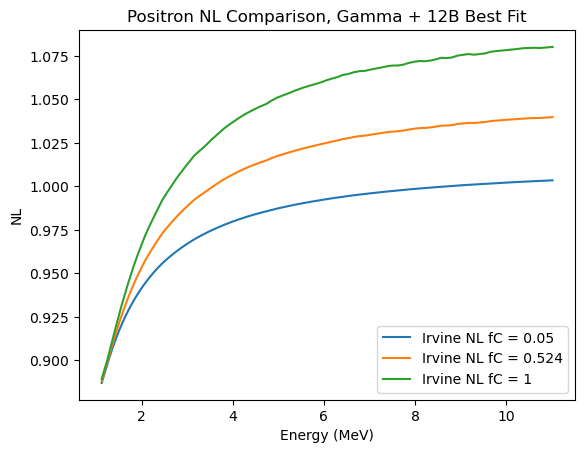

In [57]:
B_root = uproot.open("./Positron_result_plot_Oct22.root")
andrea_root = uproot.open("./NL_gamma_B12_C11.root")

print(B_root.keys())
g = andrea_root["nl_positron"]
gb = B_root["resolution"]# or whatever your graph name is
ge = B_root["energy"]

energy_array  = g.member("fX")   # numpy array of x values
andrea_nl  = g.member("fY")   # numpy array of y values

b_array  = gb.member("fX")   # numpy array of x values
b_nl  = gb.member("fY")   # numpy array of y values

b_energx  = ge.member("fX")   # numpy array of x values
b_energy  = ge.member("fY")   # numpy array of y values

#E_grid, quench_factor, dEdx = birks_integral(12.05e-3, 0.86, juno_stopping, E_vals)
#roberto = scint_model(evis_array, 1.013, 12.05e-3, 0.019, 0.86, juno_stopping, E_vals, positron, cherenkov)
pos_1 = beta_scint(yx, *popt[0:2], 0.05, 0.859, juno_stopping, E_vals, positron, cherenkov, True)
pos_2 = beta_scint(yx, *popt[0:2], 0.5, 0.859, juno_stopping, E_vals, positron, cherenkov, True)
pos_3 = beta_scint(yx, *popt[0:2], 1, 0.859, juno_stopping, E_vals, positron, cherenkov, True)
plt.plot(e_positron, pos_1, label="Irvine NL fC = 0.05")
plt.plot(e_positron, pos_2, label="Irvine NL fC = 0.524")
plt.plot(e_positron, pos_3, label="Irvine NL fC = 1")
#plt.plot(energy_array, andrea_nl, label='Padova NL', color='coral')
#plt.plot(b_energx, b_energy, label='Group B NL', color='forestgreen', alpha=0.5)

# Stack the arrays column-wise
data = np.column_stack((e_positron, pos_nl))

# Save as CSV
#np.savetxt("Irvine_beta+_nl_B12_oct29.csv", data, delimiter=",", header="E_MeV,NL", comments="")


plt.title('Positron NL Comparison, Gamma + 12B Best Fit')
plt.ylabel('NL')
plt.xlabel('Energy (MeV)')
plt.legend()
plt.savefig('cherenkov_ruins.png')

[]

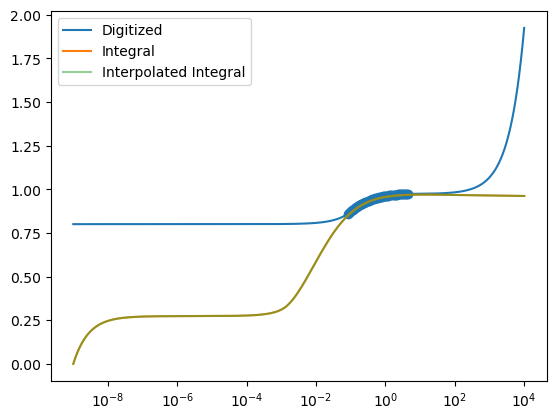

In [117]:
plt.scatter(quench[:,0], quench[:,1])
q = interp1d(quench[:,0], quench[:,1], kind='linear', fill_value='extrapolate')
qx, qy, _ = birks_integral(15.8e-3, 0.86, mass_stopping, E_vals)
qyi = interp1d(qx, qy, kind='linear', fill_value='extrapolate')
plt.plot(qx, q(qx), label='Digitized')
plt.plot(qx, qy, label='Integral')
plt.plot(qx, qyi(qx), label='Interpolated Integral', alpha=0.5)
plt.legend()
plt.semilogx()
#plt.xlim(1e-3, 20)

Running plot quenching!


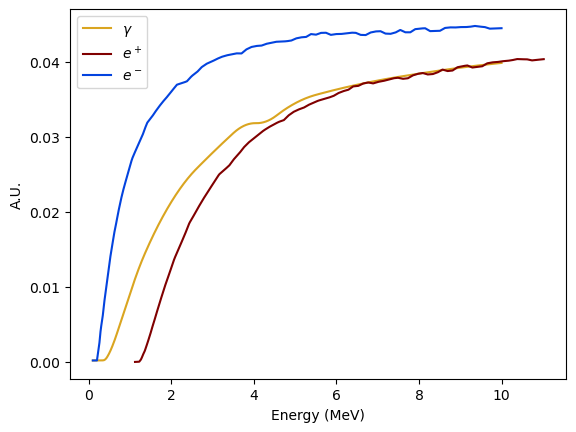

In [110]:
y_fit = scint_model(E_plot, 1.03, 12e-3, 0.52, 0.859, juno_stopping, E_vals, plot_electron, cherenkov)
y_int = interp1d(E_plot, y_fit, kind='quadratic', fill_value='extrapolate')
yx = np.linspace(1e-1, 10, n_samples) 

#make positron curve?

pos_nl = beta_scint(yx, 1.03, 12e-3, 0.52, 0.859, juno_stopping, E_vals, positron, cherenkov, True)
elec_nl = beta_scint(yx, 1.03, 12e-3, 0.52, 0.859, juno_stopping, E_vals, positron, cherenkov, False)

e_positron = yx + 2 * 0.511


#plt.errorbar(energies, data, yerr=errors, fmt='o', label="data")
plt.plot(yx, y_int(yx), '-', label=r"$\gamma$", color='goldenrod')
#plt.plot(evis_array, y_fit, '-', label="Gamma Fit")
plt.plot(e_positron, pos_nl, '-', label=r"$e^+$", color='maroon')
plt.plot(yx, elec_nl, '-', label=r"$e^-$", color='xkcd:blue')
plt.ylabel('A.U.')
plt.xlabel('Energy (MeV)')
plt.legend()
plt.savefig('cherenkov_particles.png')



In [111]:
# Stack the arrays column-wise
pdata = np.column_stack((e_positron, pos_nl))
gdata = np.column_stack((yx, y_int(yx)))
edata = np.column_stack((yx, elec_nl))

# Save as CSV
np.savetxt("Irvine_beta+_cher_B12_oct29.csv", pdata, delimiter=",", header="E_MeV,NL", comments="")
np.savetxt("Irvine_beta-_cher_B12_oct29.csv", edata, delimiter=",", header="E_MeV,NL", comments="")
np.savetxt("Irvine_gamma_cher_B12_oct29.csv", gdata, delimiter=",", header="E_MeV,NL", comments="")
